In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
import imageio
import glob
from PIL import Image, ImageDraw, ImageFont
import imageio.v2 as imageio
from rasterio.mask import mask

In [ ]:
with rasterio.open("EU_CropMap_22_v1_stratum_EU27-HR.tif") as src:
    im = src.read(1)

In [ ]:
plt.imshow(im)


In [3]:
tif_files = sorted(glob.glob("drought_data/*/*.tif"))

In [ ]:
font = ImageFont.load_default(50)

# Load images

frames = []
default_val = [158, 158, 158]

show_all_states = True

color_map = np.array(
    [
        default_val,  # no drought -> grey
        [255, 255, 0] if show_all_states else default_val,  # watch = yellow
        [255, 165, 0],  # warning = orange
        [255, 0, 0],  # alert = red
        [255, 0, 255] if show_all_states else default_val,  # recovery = bright purple
        [128, 0, 128] if show_all_states else default_val,  # temporary soil moisture recovery = dark purple
        [0, 255, 0] if show_all_states else default_val,  # temporary vegetation recovery = green
        [0, 255, 0],  # placeholder - should not be used
        [176, 240, 255],  # water body - blue
    ],
    dtype=np.uint8,
)


for file in tif_files:
    with rasterio.open(file) as src:
        im = src.read(1)
        profile = src.profile
    im = color_map[im]
    im = np.clip(im, 0, 255).astype(np.uint8)
    im = Image.fromarray(im)

    draw = ImageDraw.Draw(im)
    draw.text(
        (10, 10),
        file.split("_")[-4],
        fill="black",
        stroke_width=5,
        stroke_fill="white",
        font=font,
    )

    frames.append(im)

In [ ]:
filename = f"CDI_2012-2024_{"full" if show_all_states else "warning"}"

def save_pil_images_to_mp4(images, output_path, fps=30):
    with imageio.get_writer(
        output_path,
        format="ffmpeg",
        mode="I",
        fps=fps,
        codec="libx264",
        quality=8,
        pixelformat="yuv420p",
    ) as writer:
        for img in images:
            writer.append_data(np.array(img))

save_pil_images_to_mp4(frames, filename + ".mp4", fps=5)

In [ ]:

# Save as GIF
frames[0].save(
    filename + ".gif",
    save_all=True,
    append_images=frames[1:],
    duration=200,   # milliseconds per frame
    loop=0        # 0 = infinite loop
)

<Axes: >

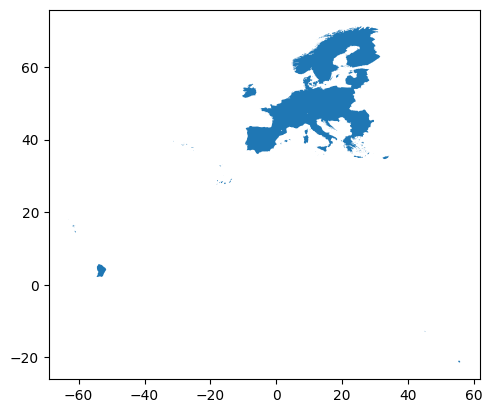

In [ ]:
eu = gpd.read_file("CNTR_RG_10M_2024_4326.shp")
eu = eu[(eu["EU_STAT"] == "T") | eu["CNTR_ID"].isin(["NO", "CH"])] # EU + Norway and Switzerland
eu = eu.dissolve()
eu.geometry.plot()

In [ ]:
water_val = 0
default_val = 1
watch_val = 2
warning_val = 3
drought_val = 4

drought_index_mapper= np.array(
    [
        default_val,  # no drought -> grey
        watch_val,  # watch = yellow
        warning_val,  # warning = orange
        drought_val,  # alert = red
        default_val,  # recovery = bright purple
        default_val,  # temporary soil moisture recovery = dark purple
        default_val,  # temporary vegetation recovery = green
        water_val,  # placeholder - should not be used
        water_val,  # water body - blue
    ],
    dtype=np.uint8,
)   

In [112]:
masked_frames = []

for file in tif_files:
    with rasterio.open(file) as src:
        im_masked, transform = mask(
                src,
                eu.geometry,
                all_touched=True,
                crop=True,
                pad=True, # TODO: recheck the parametrization on this function call!
                nodata=8 # we pretend that any pixel that is not in the EU mask is covered by water
                )
        im_masked = im_masked[0] # remove redundant dimension
        im_masked = drought_index_mapper[im_masked]
        masked_frames.append(im_masked)

frames_ar = np.array(masked_frames)

xmin, xmax = 300, 1350
ymin, ymax = 0, 900

frames_ar = frames_ar[:,ymin:ymax, xmin:xmax], 

water_mask = frames_ar == water_val


In [113]:
n = frames_ar.shape[0]
x = np.arange(n)

X = np.column_stack((np.ones(n), x)) # (n, 2)
Y = frames_ar.reshape(n, -1) # (n, d1*d2)

beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
intercepts, slopes = beta.reshape(2, *frames_ar.shape[1:])

AttributeError: 'tuple' object has no attribute 'shape'

/var/folders/1_/j9jx95wx4zv29v6wh_ztx5_r0000gp/T/ipykernel_5754/2969170754.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


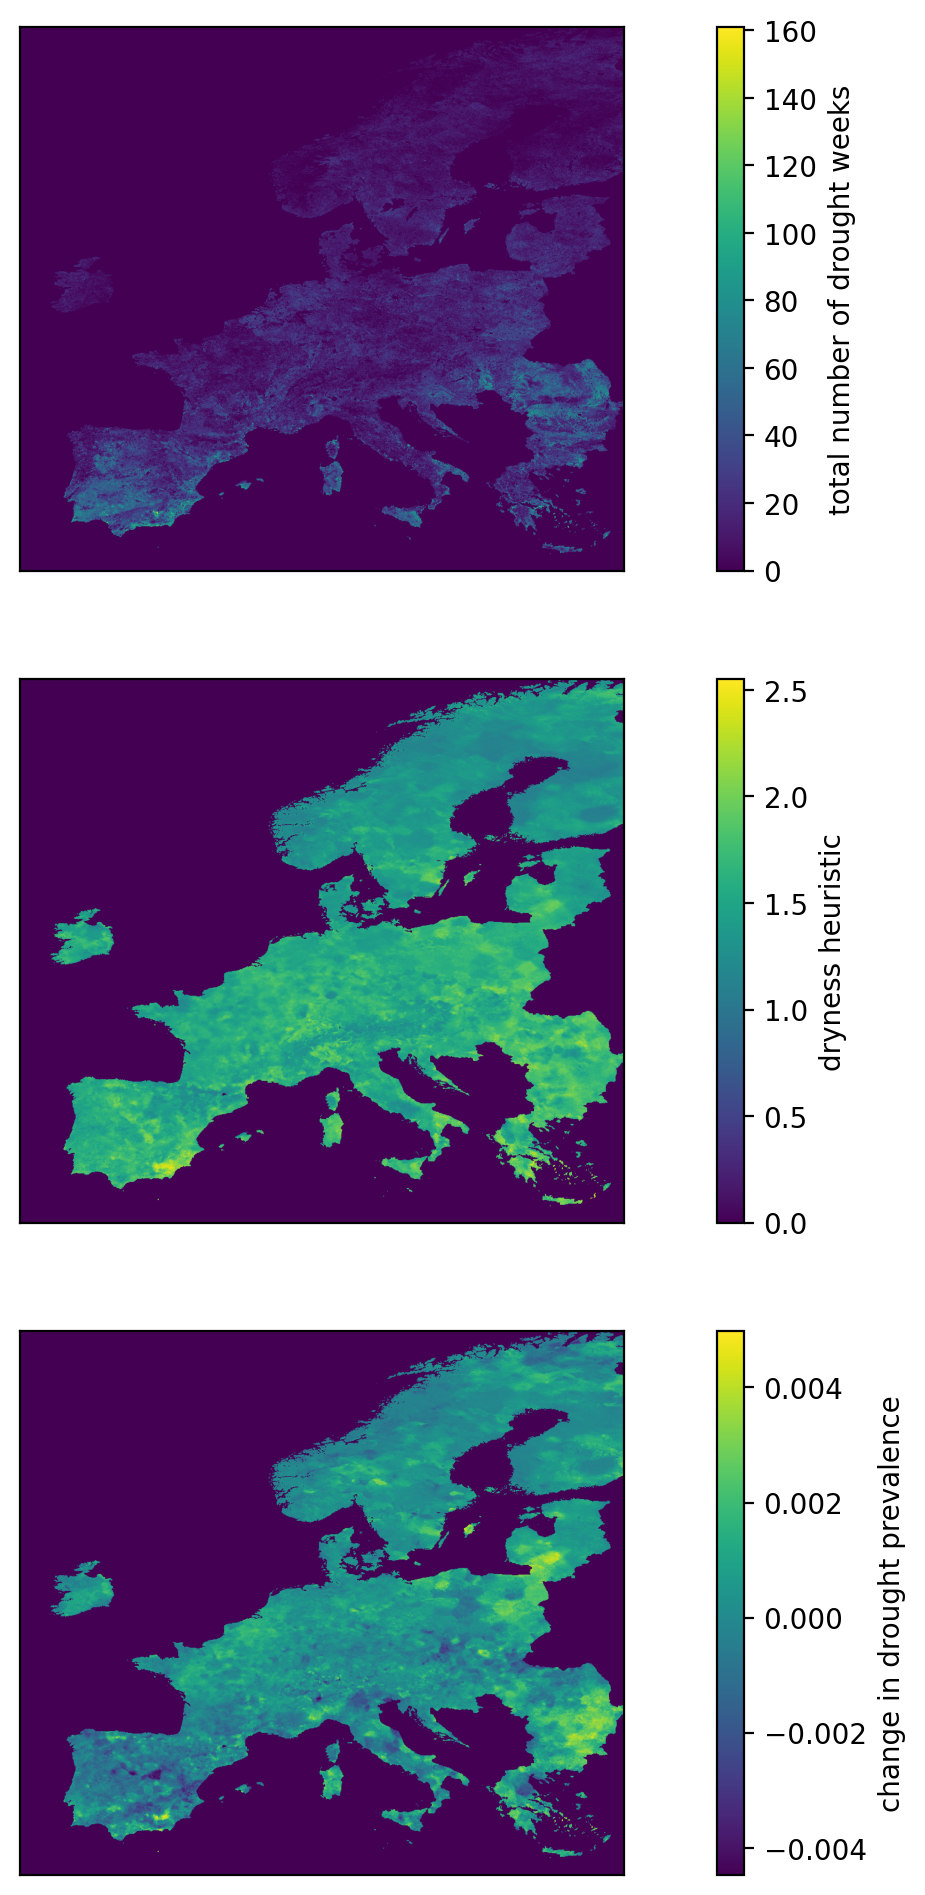

In [ ]:
xmin, xmax = 300, 1350
ymin, ymax = 0, 900

fig, axs = plt.subplots(3,1, figsize=(12,12), dpi=200)
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

total_drought_periods = (frames_ar == drought_val).sum(axis=0)
total_drought_periods[water_mask[0]] = total_drought_periods.min()

im = axs[0].imshow(total_drought_periods)
fig.colorbar(im, ax=axs[0], label="total number of drought weeks")


drought_estimate = frames_ar.mean(axis=0)
drought_estimate[water_mask[0]] = drought_estimate.min()

im = axs[1].imshow(drought_estimate)
fig.colorbar(im, ax=axs[1], label="dryness heuristic")


slopes[water_mask[0]] = slopes.min()
slopes[slopes ]
im = axs[2].imshow(slopes)
fig.colorbar(im, ax=axs[2], label="change in drought prevalence")


fig.show()


In [2]:
df_year = pd.read_csv("cdi4_by_nuts3_y.csv")
df_month = pd.read_csv("cdi4_by_nuts3_m.csv")

In [3]:
len(df_year), len(df_month)

(3498, 34980)

In [4]:
groups = df_month.groupby("NUTS_CODE")

In [5]:
month_groups = df_month.groupby("REF_DATE")

In [6]:
dates = []
p2_mean = []
p3_mean = []
p23_mean = []

for g in month_groups:
    date, data = g
    dates.append(date)
    p2_mean.append(data["PERC_2"].mean())
    p3_mean.append(data["PERC_3"].mean())
    p23_mean.append(data["PERC_2_OR_3"].mean())

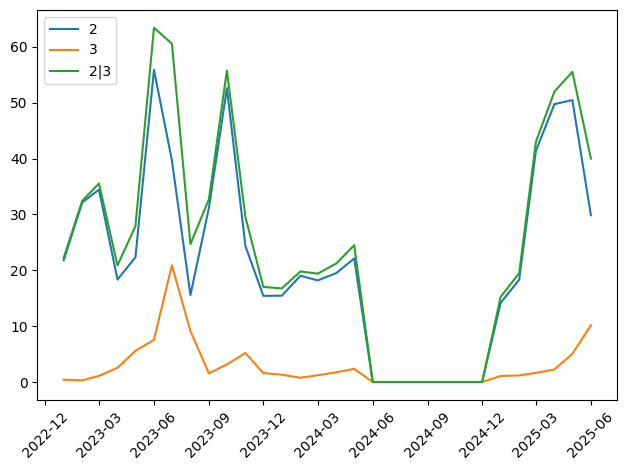

In [7]:
import matplotlib.dates as mdates
dates = pd.to_datetime(dates)
fig, ax = plt.subplots()
ax.plot(dates, p2_mean, label="2")
ax.plot(dates, p3_mean, label="3")
ax.plot(dates, p23_mean, label="2|3")
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df_2024 = df_year[df_year["YEAR"]==2023]

In [11]:
df_2024[["NUTS_CODE", "MAX_PERC_3"]].to_csv("foo.csv")